In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os, warnings
warnings.filterwarnings('ignore')

2026-02-28 15:45:06.436995: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-28 15:45:06.473667: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-28 15:45:07.386036: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [4]:
X_train = np.load('../data/X_train.npy')
X_val   = np.load('../data/X_val.npy')

feature_df = pd.read_csv('../data/movie_features.csv')
movie_index = pd.read_csv('../data/movie_index.csv')

with open('../data/feature_cols.txt') as f:
    feature_cols = f.read().splitlines()

dim = X_train.shape[1]
embbeding_dim = 32

In [5]:
feature_df.head()

,movieId,title,genres,year,genre_(no genres listed),genre_Action,genre_Adventure,genre_Animation,genre_Children,genre_Comedy,...,svd_22,svd_23,svd_24,svd_25,svd_26,svd_27,svd_28,svd_29,svd_30,svd_31
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995,0,0,1,1,1,1,...,0.059890,0.047930,0.042637,-0.018202,-0.014047,-0.056507,-0.027629,0.029763,0.130132,-0.143215
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995,0,0,1,0,1,0,...,0.065462,0.109900,0.074042,0.012675,0.093461,-0.061287,0.000245,0.017599,0.022820,0.059481
2,3,Grumpier Old Men (1995),Comedy|Romance,1995,0,0,0,0,0,1,...,-0.023063,0.200771,-0.089993,-0.069429,-0.107916,-0.117377,0.106607,0.076988,0.260566,0.012340
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995,0,0,0,0,0,1,...,-0.100949,0.307935,-0.018332,0.051203,0.012859,-0.088717,0.227507,0.163504,-0.105331,0.009553
4,5,Father of the Bride Part II (1995),Comedy,1995,0,0,0,0,0,1,...,-0.134975,0.323358,0.060103,-0.023971,-0.217256,-0.052733,0.165734,0.028011,0.083844,0.053335


## Autoencoder Model for Movie Embeddings

An autoencoder is a neural network that learns to reconstruct its input.  
It consists of two main parts:

- **Encoder**: compresses the input features into a lower-dimensional representation (embedding).
- **Decoder**: reconstructs the original input from the embedding.

### Model Architecture

- Input layer: `input_dim` features per movie  
- Encoder hidden layers: 128 → 64 (ReLU activation)  
- Bottleneck layer: `embedding_dim` (compressed movie representation)  
- Decoder: symmetric mirror of the encoder  
- Output layer: reconstructs the original input vector  

Model is trained using **Mean Squared Error (MSE)** loss with the Adam optimizer.

After training:
- The **autoencoder** is used during training to minimize reconstruction error.
- The **encoder** model is used separately to extract movie embedding vectors.

In [6]:
def build_autoencoder(input_dim, embedding_dim,
                      encoder_layers=(128, 64),
                      dropout_rate=0.1,
                      learning_rate=0.001):
    # Encoder
    inp = layers.Input(shape=(input_dim,), name='movie_input')
    x   = inp
    for i, units in enumerate(encoder_layers):
        x = layers.Dense(units, activation='relu', name=f'enc_{i}')(x)
        if i == 0:
            x = layers.Dropout(dropout_rate)(x)
    embed = layers.Dense(embedding_dim, activation='relu', name='embedding')(x)

    # Decoder
    x = embed
    for i, units in enumerate(reversed(encoder_layers)):
        x = layers.Dense(units, activation='relu', name=f'dec_{i}')(x)
        if i == len(encoder_layers) - 1:
            x = layers.Dropout(dropout_rate)(x)
    out = layers.Dense(input_dim, activation='linear', name='reconstruction')(x)

    autoencoder = keras.Model(inputs=inp, outputs=out,   name='autoencoder')
    encoder     = keras.Model(inputs=inp, outputs=embed, name='encoder')

    autoencoder.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse'
    )
    return autoencoder, encoder

autoencoder, encoder = build_autoencoder(dim, embbeding_dim)
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ movie_input (InputLayer)        │ (None, 57)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_0 (Dense)                   │ (None, 128)            │         7,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_1 (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_0 (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_1 (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 57)             │         7,353 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,545 (138.85 KB)

 Trainable params: 35,545 (138.85 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True, verbose=1
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5, verbose=1
)

history = autoencoder.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0556 - val_loss: 0.0240 - learning_rate: 0.0010
Epoch 2/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0247 - val_loss: 0.0174 - learning_rate: 0.0010
Epoch 3/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0192 - val_loss: 0.0142 - learning_rate: 0.0010
Epoch 4/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0166 - val_loss: 0.0124 - learning_rate: 0.0010
Epoch 5/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0148 - val_loss: 0.0112 - learning_rate: 0.0010
Epoch 6/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0136 - val_loss: 0.0104 - learning_rate: 0.0010
Epoch 7/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0126 - val_loss: 0.0094 - learning_rate: 0.0010
Epoch 8/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0118 - val_loss: 0.0088 - learning_rate: 0.0010
Epoch 9/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0112 - val_loss: 0.0086 - learning_rate: 0.0010
Epoch 10/5

Text(0.5, 1.0, 'Loss Curves')

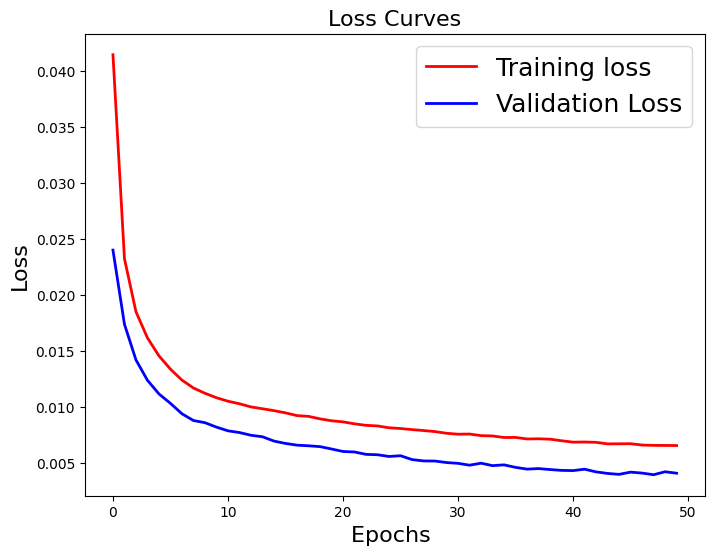

In [8]:
from matplotlib import pyplot as plt
plt.figure(figsize=[8,6])
plt.plot(history.history['loss'],'r',linewidth=2.0)
plt.plot(history.history['val_loss'],'b',linewidth=2.0)
plt.legend(['Training loss', 'Validation Loss'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Loss',fontsize=16)
plt.title('Loss Curves',fontsize=16)
  

In [11]:
X_all  = feature_df[feature_cols].values.astype(np.float32)
embeds = encoder.predict(X_all, batch_size=256, verbose=0)

norms  = np.linalg.norm(embeds, axis=1, keepdims=True) + 1e-8
embeddings = embeds / norms

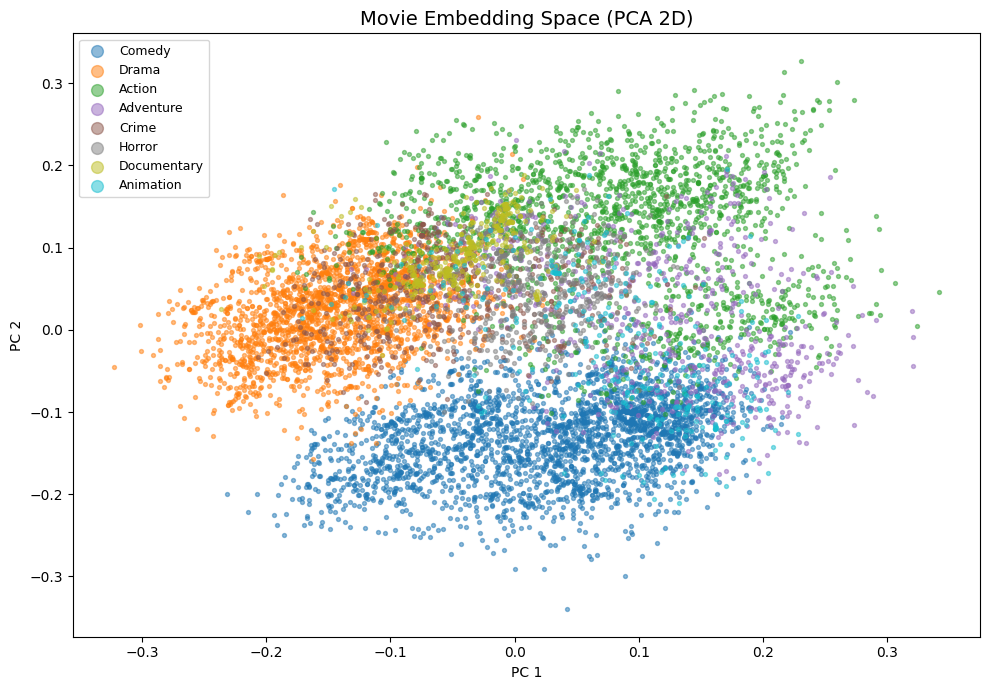

In [12]:
from sklearn.decomposition import PCA

pca   = PCA(n_components=2, random_state=42)
emb2d = pca.fit_transform(embeddings)

primary_genre = feature_df['genres'].str.split('|').str[0]
top_genres    = primary_genre.value_counts().head(8).index.tolist()
colours       = plt.cm.tab10(np.linspace(0, 1, len(top_genres)))

plt.figure(figsize=(10, 7))
for genre, colour in zip(top_genres, colours):
    mask = primary_genre == genre
    plt.scatter(emb2d[mask, 0], emb2d[mask, 1],
                c=[colour], label=genre, alpha=0.5, s=8)
plt.legend(markerscale=3, fontsize=9)
plt.title('Movie Embedding Space (PCA 2D)', fontsize=14)
plt.xlabel('PC 1'); plt.ylabel('PC 2')
plt.tight_layout(); plt.show()

## Visualization of the Movie Embedding Space (PCA Projection)

The figure above shows a 2D visualization of the learned movie embeddings.

Since the embedding vectors live in a high-dimensional space, we apply 
**Principal Component Analysis (PCA)** to project them onto two dimensions.

### Interpretation

- Each point represents a movie.
- Colors correspond to movie genres.
- The axes (PC1 and PC2) are the first two principal components capturing
  the largest variance in the embedding space.

Movies that appear close together in this plot have similar embedding vectors,
which means they are similar according to user viewing behavior.

### Observations

- Certain genres (e.g., Comedy, Animation) form visible clusters.
- Some genres overlap, indicating shared audience patterns.
- Even though genre labels were not explicitly used to define similarity,
  the embedding space naturally organizes movies in a semantically meaningful way.

This suggests that the model successfully captured underlying co-watching
and behavioral patterns in the data.

In [15]:
# We use this function to get the correct name of the movie
def find_movie(query, df=feature_df, n=5):
    matches = df[df['title'].str.lower().str.contains(query.lower(), regex=False)]
    result  = matches[['movieId','title','genres','year']].head(n)
    if result.empty:
        print(f'No matches found for "{query}"')
    return result

In [16]:
def recommend(liked_titles, top_n=10, df=feature_df, embeddings=embeddings):
    liked_ids, liked_vecs = [], []

    for title in liked_titles:
        matches = df[df['title'].str.lower().str.contains(title.lower(), regex=False)]
        if matches.empty:
            print(f'  Warning: "{title}" not found — skipping.')
            continue
        row = matches.iloc[0]
        liked_ids.append(row['movieId'])
        liked_vecs.append(embeddings[row.name])
        print(f'  Matched: {row["title"]} ({int(row["year"])})')

    if not liked_vecs:
        print('No valid movies found.')
        return pd.DataFrame()

    query = np.mean(liked_vecs, axis=0, keepdims=True)
    query = query / (np.linalg.norm(query) + 1e-8)

    sims   = cosine_similarity(query, embeddings)[0]
    result = df[['movieId','title','genres','year']].copy()
    result['similarity'] = sims
    result = result[~result['movieId'].isin(liked_ids)]
    result = result.sort_values('similarity', ascending=False).head(top_n)
    result['year']       = result['year'].astype(int)
    result['similarity'] = result['similarity'].round(4)
    return result.reset_index(drop=True)

In [17]:
find_movie('inception')

,movieId,title,genres,year
7354,79132,Inception (2010),Action|Crime|Drama|Mystery|Sci-Fi|Thriller|IMAX,2010


In [18]:
find_movie('interstellar')

,movieId,title,genres,year
8357,109487,Interstellar (2014),Sci-Fi|IMAX,2014


In [19]:
recs = recommend(['Inception', 'Matrix', 'Interstellar'], top_n=10)

print(recs[['title','genres','year','similarity']].to_string(index=False))

  Matched: Inception (2010) (2010)
  Matched: Matrix, The (1999) (1999)
  Matched: Interstellar (2014) (2014)
                                                title                                genres  year  similarity
                                V for Vendetta (2006)           Action|Sci-Fi|Thriller|IMAX  2006      0.9841
                              Edge of Tomorrow (2014)                    Action|Sci-Fi|IMAX  2014      0.9771
                          Matrix Reloaded, The (2003) Action|Adventure|Sci-Fi|Thriller|IMAX  2003      0.9738
                       Matrix Revolutions, The (2003) Action|Adventure|Sci-Fi|Thriller|IMAX  2003      0.9731
                                       Gravity (2013)                    Action|Sci-Fi|IMAX  2013      0.9731
                                      Iron Man (2008)               Action|Adventure|Sci-Fi  2008      0.9719
                    Terminator 2: Judgment Day (1991)                         Action|Sci-Fi  1991      0.9719
          

In [20]:
recs = recommend(['Dark Knight', 'Pulp Fiction', 'Se7en'], top_n=10)

print(recs[['title','genres','year','similarity']].to_string(index=False))

  Matched: Dark Knight, The (2008) (2008)
  Matched: Pulp Fiction (1994) (1994)
  Matched: Seven (a.k.a. Se7en) (1995) (1995)
                                                         title                      genres  year  similarity
                                             Fight Club (1999) Action|Crime|Drama|Thriller  1999      0.9844
                                        Green Mile, The (1999)                 Crime|Drama  1999      0.9827
                              Shawshank Redemption, The (1994)                 Crime|Drama  1994      0.9825
Léon: The Professional (a.k.a. The Professional) (Léon) (1994) Action|Crime|Drama|Thriller  1994      0.9824
                                         Godfather, The (1972)                 Crime|Drama  1972      0.9817
                                     American History X (1998)                 Crime|Drama  1998      0.9816
                                    Catch Me If You Can (2002)                 Crime|Drama  2002      0.9813
  